# Investigative Statistical Analysis

## Analysing Accuracy in Data

### Introduction

Data journalist, Walt Hickey, published an analysis of online movie ratings aggregator, [Fandango](https://www.fandango.com/), that showed that there was a discrepancy between the number of stars displayed and the actual rating, evidence that their star rating system was biased and dishonest. The star rating system is an aggregation of ratings from zero to five stars. The article can be viewed [here](https://fivethirtyeight.com/features/fandango-movies-ratings/).

This report will analyse movie ratings data to establish whether there has been a change in the ratings system following Fandango's assertion that the above was due to a bug in their system that they were going to rectify 'as soon as possible'.

### Understanding the Data

This anlysis will compare publicly available datasets, both from Hickey's original analysis (available on [GitHub here](https://github.com/fivethirtyeight/data/tree/master/fandango)) and ratings for movies released in 2016 and 2017 (available on [GitHub here](https://github.com/mircealex/Movie_ratings_2016_17)).

In [1]:
# Import required libraries and packages
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
old_df = pd.read_csv('fandango_score_comparison.csv')
new_df = pd.read_csv('movie_ratings_16_17.csv')

In [3]:
old_df.head()

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Fandango_Stars,Fandango_Ratingvalue,RT_norm,RT_user_norm,...,IMDB_norm,RT_norm_round,RT_user_norm_round,Metacritic_norm_round,Metacritic_user_norm_round,IMDB_norm_round,Metacritic_user_vote_count,IMDB_user_vote_count,Fandango_votes,Fandango_Difference
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,5.0,4.5,3.70,4.3,...,3.90,3.5,4.5,3.5,3.5,4.0,1330,271107,14846,0.5
1,Cinderella (2015),85,80,67,7.5,7.1,5.0,4.5,4.25,4.0,...,3.55,4.5,4.0,3.5,4.0,3.5,249,65709,12640,0.5
2,Ant-Man (2015),80,90,64,8.1,7.8,5.0,4.5,4.00,4.5,...,3.90,4.0,4.5,3.0,4.0,4.0,627,103660,12055,0.5
3,Do You Believe? (2015),18,84,22,4.7,5.4,5.0,4.5,0.90,4.2,...,2.70,1.0,4.0,1.0,2.5,2.5,31,3136,1793,0.5
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,3.5,3.0,0.70,1.4,...,2.55,0.5,1.5,1.5,1.5,2.5,88,19560,1021,0.5


In [4]:
new_df.head()

,movie,year,metascore,imdb,tmeter,audience,fandango,n_metascore,n_imdb,n_tmeter,n_audience,nr_metascore,nr_imdb,nr_tmeter,nr_audience
0,10 Cloverfield Lane,2016,76,7.2,90,79,3.5,3.80,3.60,4.50,3.95,4.0,3.5,4.5,4.0
1,13 Hours,2016,48,7.3,50,83,4.5,2.40,3.65,2.50,4.15,2.5,3.5,2.5,4.0
2,A Cure for Wellness,2016,47,6.6,40,47,3.0,2.35,3.30,2.00,2.35,2.5,3.5,2.0,2.5
3,A Dog's Purpose,2017,43,5.2,33,76,4.5,2.15,2.60,1.65,3.80,2.0,2.5,1.5,4.0
4,A Hologram for the King,2016,58,6.1,70,57,3.0,2.90,3.05,3.50,2.85,3.0,3.0,3.5,3.0


In [5]:
old_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    object 
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Fandango_Stars              146 non-null    float64
 7   Fandango_Ratingvalue        146 non-null    float64
 8   RT_norm                     146 non-null    float64
 9   RT_user_norm                146 non-null    float64
 10  Metacritic_norm             146 non-null    float64
 11  Metacritic_user_nom         146 non-null    float64
 12  IMDB_norm                   146 non-null    float64
 13  RT_norm_round               146 non

In [6]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie         214 non-null    object 
 1   year          214 non-null    int64  
 2   metascore     214 non-null    int64  
 3   imdb          214 non-null    float64
 4   tmeter        214 non-null    int64  
 5   audience      214 non-null    int64  
 6   fandango      214 non-null    float64
 7   n_metascore   214 non-null    float64
 8   n_imdb        214 non-null    float64
 9   n_tmeter      214 non-null    float64
 10  n_audience    214 non-null    float64
 11  nr_metascore  214 non-null    float64
 12  nr_imdb       214 non-null    float64
 13  nr_tmeter     214 non-null    float64
 14  nr_audience   214 non-null    float64
dtypes: float64(10), int64(4), object(1)
memory usage: 25.2+ KB


We can see from the above that both datasets look clean with correct data types and are ready for analysis. There is a difference in that the film title and year of release are separate fields in the new dataset and combined in the original.

To concentrate on comparing Fandango's ratings, the datasets will be filtered to only the relevant columns.

In [7]:
old_df = old_df[['FILM', 'Fandango_Stars', 'Fandango_Ratingvalue', 'Fandango_votes', 'Fandango_Difference']]
new_df = new_df[['movie', 'year', 'fandango']]

The documentation for the datasets tells us that:
* The original dataset only looks at films with 30 reviews or more that were released in 2015.
* The new dataset looks at films that were released in 2016 or later.
* It is unknown whether there was any restriction on the number of reviews was made on the new dataset.
* There is no way of knowing whether films released in any of the years involved were, in general, better or worse than other years.

It therefore seems unlikely that these data reflect the entire population of films rated on the Fandango website.

In light of this, the comparison will be made between data from the first dataset for films released in 2015 and films from the second dataset released in 2016.

The release year from the original dataset will need to be extracted from the `FILM` column.

### Isolate the Required Samples

In [8]:
old_df['Year'] = old_df['FILM'].apply(lambda x: x[-5:-1]).astype('int')

In [9]:
films_2015 = old_df[old_df['Year'] == 2015].copy()
films_2016 = new_df[new_df['year'] == 2016].copy()

### Comparing Distribution Shapes for 2015 and 2016

Compare the shape of the distributions of both datasets with a Kernel Density plot.

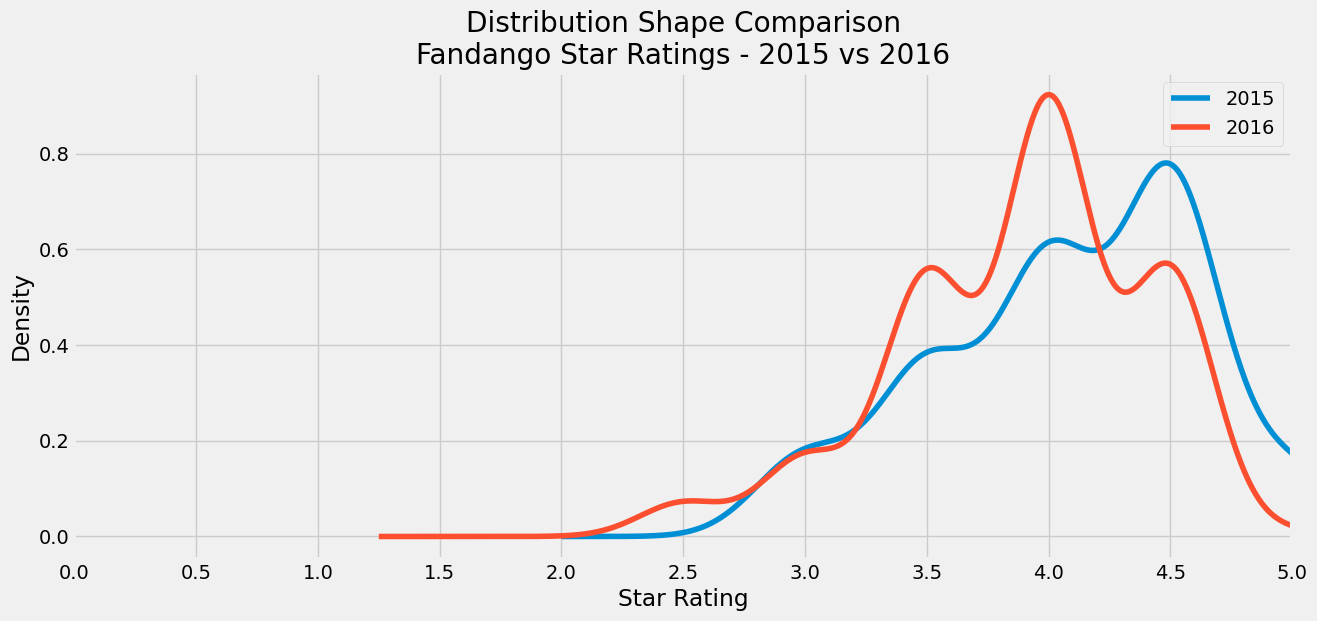

In [10]:
xtick_labels = [n / 2 for n in range(0, 11)]

plt.style.use('fivethirtyeight')

films_2015['Fandango_Stars'].plot.kde(figsize=(14, 6),
                                     label='2015',
                                     legend=True)
films_2016['fandango'].plot.kde(label='2016',
                                legend=True)
plt.title('Distribution Shape Comparison\nFandango Star Ratings - 2015 vs 2016')
plt.xlabel('Star Rating')
plt.xlim(0, 5)
plt.xticks(xtick_labels)
plt.show()

The above chart shows that both distributions are strongly left skewed.

The 2016 distribution is slightly to the left of the 2015 distribution.

This seems to indicate that films had star ratings slightly lower on average in 2016 than 2015. At this point, it is not clear whether the rounding issue has been corrected or films were generally not received as well in 2016 compared to 2015.

### Comparing Relative Frequencies

Examine the frequency distribution tables for both datasets. As the datasets contain a different number of films, the distribution tables will show percentages.

In [11]:
print('2015')
print(films_2015['Fandango_Stars'].value_counts(normalize=True).sort_index() * 100)

2015
Fandango_Stars
3.0     8.527132
3.5    17.829457
4.0    28.682171
4.5    37.984496
5.0     6.976744
Name: proportion, dtype: float64


In [12]:
print('2016')
print(films_2016['fandango'].value_counts(normalize=True).sort_index() * 100)

2016
fandango
2.5     3.141361
3.0     7.329843
3.5    24.083770
4.0    40.314136
4.5    24.607330
5.0     0.523560
Name: proportion, dtype: float64


The tables show a reduction (approximately 20%) in the proportion of films rated 4.5 and 5 stars from 2015 to 2016.

They also show an increase (almost 20%) in the proporation of films rated 3.5 and 4 stars from 2015 to 2016.

Whilst there are some 2.5 star ratings in 2016 compared to none in 2015 there is only a 3% increase in 3 or less stars from the two datasets.

### Determining the Direction of the Change

To try to ascertain the direction of change, calculate the mean, median and mode for each distribution.

In [13]:
mean_2015 = films_2015['Fandango_Stars'].mean()
median_2015 = films_2015['Fandango_Stars'].median()
mode_2015 = films_2015['Fandango_Stars'].mode()[0]

mean_2016 = films_2016['fandango'].mean()
median_2016 = films_2016['fandango'].median()
mode_2016 = films_2016['fandango'].mode()[0]

summary = pd.DataFrame()
summary['2015'] = [mean_2015, median_2015, mode_2015]
summary['2016'] = [mean_2016, median_2016, mode_2016]
summary.index = ['mean', 'median', 'mode']
summary

,2015,2016
mean,4.085271,3.887435
median,4.000000,4.000000
mode,4.500000,4.000000


It can be seen that there is a slight reduction in the means of the distributions from 2015 to 2016 with no change in the median values.

The most common value in 2015 was 4.5. This reduced to 4.0 in 2016.

Show a grouped bar plot to show how these summary statistics varied from 2015 to 2016.

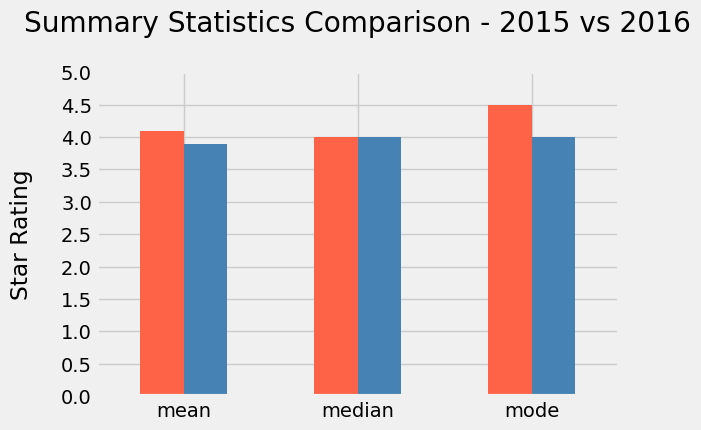

In [25]:
summary['2015'].plot.bar(figsize=(6,4),
                         color='tomato',
                         width=-0.25,
                         align='edge',
                         label='2015',
                         rot=0)
summary['2016'].plot.bar(color='steelblue',
                         width=0.25,
                         align='edge',
                         label='2016',
                         rot=0)
plt.title('Summary Statistics Comparison - 2015 vs 2016',
          y=1.1)
plt.ylabel('Star Rating', labelpad=20)
plt.ylim(0, 5)
plt.yticks(xtick_labels)
plt.xlim(-0.5, len(summary) - 0.5)
plt.show()

### Conclusion

The above analysis does show that there was a downward trend in Fandago's star ratings of films released in 2016 compared to 2015.

However, from the data available, it is unclear whether this is due to the films being subjectively worse or the rounding up issue was resolved.

The most direct way of answering that question would be to obtain the rating and star rating for comparison in the 2016 dataset for analysis.